# Example: Static vs Adaptive, Head-to-Head on 5,000 Paths

The previous notebook showed the engine's distributional behavior in isolation. This notebook asks a sharper question: on each individual forward path, did the Cobb-Douglas engine outperform the Session 1 static min-var portfolio, and if so, **when**? Loading the per-path arrays from `stress-test-engine.jld2`, we build three complementary views:

* __Per-path excess-wealth distribution:__ Subtract min-var terminal wealth from engine terminal wealth path-by-path, then summarize with win rate, median excess, and excess CVaR.
* __Regime-conditional scatter:__ Plot per-path excess against per-path market return and fit a conditional mean to see whether the engine wins more in bull, bear, or sideways markets.
* __Paired quantile comparison:__ Sort paths by min-var wealth and plot both strategies on the same rank axis to expose where in the distribution the adaptive strategy earns its premium.

Together the three views answer "when does adaptivity pay off?" in a way the marginal scorecard cannot. The bear-conditioned fifth-percentile wealth figure produced here is the number Maya walks into Thursday's risk committee with in the [Session 2 introduction](eCornell-AI-Finance-S2-Introduction-MayasAdaptiveEngine-May-2026.ipynb).

> __Learning Objectives:__
>
> * __Compute per-path excess wealth:__ Subtract the Session 1 min-var terminal wealth from the engine terminal wealth on a path-by-path basis to get an excess distribution. Summarize by win rate, median excess, and excess CVaR.
> * __Diagnose regime dependence:__ Scatter the per-path excess against the per-path market return and fit a simple conditional mean. See whether the engine wins more in bull, bear, or sideways markets.
> * __Build a paired quantile view:__ Sort paths by min-var wealth, plot both strategies side-by-side on the same rank axis, and compute the quantile-by-quantile excess. This exposes where in the distribution the adaptive strategy earns its premium.

Let's dive in!

___

## Setup, Data and Prerequisites

In [1]:
include("Include.jl");

### Constants


In [2]:
# Comparison inputs
STRESS_TEST_RESULTS_PATH = joinpath(_PATH_TO_DATA, "stress-test-engine.jld2")  # per-path stress-test arrays saved by the StressTest notebook
EXCESS_TAIL_FRACTION = 0.05  # tail fraction for CVaR of excess wealth (worst 5% of paths)

0.05

Load the 5,000-path per-path arrays from the stress-test notebook. The `let...end` block below reads `stress-test-engine.jld2` and returns: `n_paths::Int`, `n_steps::Int`, `offset::Int`, `B₀::Float64`, `g_f::Float64`, `discount::Float64`, `eng_W::Vector{Float64}`, `eng_DD::Vector{Float64}`, `eng_SR::Vector{Float64}`, `eng_NPV::Vector{Float64}`, `mv_W::Vector{Float64}`, `mv_DD::Vector{Float64}`, `mv_SR::Vector{Float64}`, `mv_NPV::Vector{Float64}`, and `market_return::Vector{Float64}`. These are the inputs for every subsequent analysis.

In [3]:
n_paths, n_steps, offset, B₀, g_f, discount, eng_W, eng_DD, eng_SR, eng_NPV, mv_W, mv_DD, mv_SR, mv_NPV, market_return = let
    data = load_results(STRESS_TEST_RESULTS_PATH);

    # --- Step 1: Scalar constants ---
    n_paths  = Int(data["n_paths"]);
    n_steps  = Int(data["n_steps"]);
    offset   = Int(data["offset"]);
    B₀       = Float64(data["B₀"]);
    g_f      = Float64(data["g_f"]);
    discount = Float64(data["discount"]);

    # --- Step 2: Per-path engine arrays ---
    eng_W    = Float64.(data["eng_final_wealth"]);
    eng_DD   = Float64.(data["eng_max_drawdowns"]);
    eng_SR   = Float64.(data["eng_sharpe_ratios"]);
    eng_NPV  = Float64.(data["eng_npv"]);

    # --- Step 3: Per-path S1 min-var arrays ---
    mv_W     = Float64.(data["mv_final_wealth"]);
    mv_DD    = Float64.(data["mv_max_drawdowns"]);
    mv_SR    = Float64.(data["mv_sharpe_ratios"]);
    mv_NPV   = Float64.(data["mv_npv"]);

    # --- Step 4: Per-path market regime indicator ---
    market_return = Float64.(data["market_return"]);

    println("Loaded $(n_paths)-path arrays from stress-test-engine.jld2")
    println("  Engine:   median W/W₀ = $(round(median(eng_W)/B₀, digits=3))")
    println("  Min-Var:  median W/W₀ = $(round(median(mv_W)/B₀, digits=3))")
    println("  Market:   median simple return = $(round(median(market_return)*100, digits=2))%")
    n_paths, n_steps, offset, B₀, g_f, discount, eng_W, eng_DD, eng_SR, eng_NPV, mv_W, mv_DD, mv_SR, mv_NPV, market_return
end


Loaded 5000-path arrays from stress-test-engine.jld2


  Engine:   median W/W₀ = 1.38
  Min-Var:  median W/W₀ = 1.182
  Market:   median simple return = 11.76%


(5000, 336, 84, 10000.0, 0.045, 0.9559974818331, [12542.44392460576, 13640.17913128405, 15698.219348745795, 12772.0393602697, 14800.39869660483, 11716.871579427276, 12356.520900383064, 12892.721251471095, 15103.365635652484, 12129.694142783334  …  13004.878418424134, 12135.830169452347, 12756.21603622727, 12747.75579693623, 13269.400334200136, 15174.995579311464, 13216.983806399663, 14024.763041929782, 17768.76333790572, 14595.980891362173], [0.043344577307003765, 0.038307671516158846, 0.05115990515925055, 0.06242379600721156, 0.07041699915729954, 0.08649350513313957, 0.0656360542812557, 0.06847452025411403, 0.04577292937047267, 0.08027174843372463  …  0.03887104492335189, 0.04150146509522293, 0.0388337581702191, 0.036591443555331477, 0.051296348746934284, 0.04003824238779761, 0.06639803237802426, 0.04907782581064608, 0.050246683794944964, 0.041203766506058476], [2.236918168404526, 2.6014328127272237, 4.722818828735267, 1.8673100493895456, 3.330855525430046, 1.5691230542144712, 2.32317

___
## Task 1: Per-Path Excess Wealth, How Often Does the Engine Win?
For each of the 5,000 forward paths we compute the excess terminal wealth $\Delta W_p = W_p^{\text{engine}} - W_p^{\text{min-var}}$. A positive $\Delta W_p$ means the engine beat the Session 1 static portfolio on that specific path. We then summarize the excess distribution by three numbers: the **win rate** (fraction of paths with $\Delta W_p > 0$), the **median excess** in dollars, and the **CVaR$_5$ of the excess** (mean of the worst 5% of excess values, the price of adaptivity on the paths where it fails).

> __What should we see?__
>
> The excess distribution should be heavily right-skewed with a median well above zero. On this seed the engine beats min-var on the vast majority of paths. The tail CVaR should still be positive or mildly negative, meaning that even on the paths where the engine loses to min-var, it doesn't lose by much. The histogram should have a fat right tail corresponding to the paths where the engine's conviction in the top asset pays off sharply.

The `let...end` block below computes the `excess::Vector{Float64}` per-path excess array, prints the three summary statistics, and plots the excess histogram with vertical markers for zero and the median.

In [4]:
excess = let
    # --- Step 1: Per-path excess wealth ---
    excess = eng_W .- mv_W;    # engine minus static, in dollars
    excess_scaled = excess ./ B₀;      # scaled by initial wealth

    # --- Step 2: Summary statistics ---
    win_rate    = mean(excess .> 0);
    med_excess  = median(excess);
    n_tail      = max(1, floor(Int, EXCESS_TAIL_FRACTION * n_paths));
    worst_tail  = sort(excess)[1:n_tail];
    cvar_excess = mean(worst_tail);

    println("Engine-vs-Min-Var excess on $(n_paths) paths:")
    println("  Win rate:          $(round(win_rate*100, digits=2))%")
    println("  Median excess:     \$$(round(med_excess, digits=0))   (= $(round(med_excess/B₀*100, digits=2))% of B₀)")
    println("  CVaR_5 of excess:  \$$(round(cvar_excess, digits=0))   (mean of worst 5%)")
    println()
    println("Interpretation: on paths where the engine wins, it wins by $(round(mean(excess[excess.>0])/B₀*100, digits=2))% of B₀ on average.")
    println("                on paths where it loses, it loses by $(round(mean(excess[excess.<0])/B₀*100, digits=2))% of B₀ on average.")

    # --- Step 3: Excess histogram ---
    histogram(excess_scaled, bins=80, color=:steelblue, alpha=0.7,
        xlabel="Engine Excess Wealth  (W_eng − W_mv) / W₀",
        ylabel="Count", title="Per-Path Excess Wealth Distribution, Engine − S1 Min-Var",
        label="", fontsize=18, size=(900, 450));
    vline!([0.0], lw=3, ls=:dash, c=:black, label="Break-even (0)");
    vline!([med_excess / B₀], lw=3, c=:firebrick, label="Median excess");
    plot!(bg="gray95", background_color_outside="white",
        framestyle=:box, fg_legend=:transparent, legend=:topright)
    excess
end


Engine-vs-Min-Var excess on 5000 paths:


  Win rate:          96.46%
  Median excess:     $1968.0   (= 19.68% of B₀)
  CVaR_5 of excess:  $-251.0   (mean of worst 5%)

Interpretation: on paths where the engine wins, it wins by 21.01% of B₀ on average.
                on paths where it loses, it loses by -3.89% of B₀ on average.


5000-element Vector{Float64}:
 2762.048656670324
 1018.6404259901228
  869.9547582160285
 1164.0520862539852
 -161.47590990914796
 2137.335133611361
 2381.025662920918
 2431.5195090296074
 3261.11787880884
 1253.834083977501
 3118.4719070096817
 2159.926380429013
  241.62535967442636
    ⋮
 3097.8146491223215
  352.3495706966114
 2961.0196465412137
 2084.9545894990297
 1390.8420966599042
  251.48966644274878
  910.3467493863609
 3027.4221571294074
 1641.4243516157621
  900.7119765170846
 1201.397305981569
 2619.0586947086995

___
## Task 2: Regime Dependence, When Does Adaptivity Win?
The per-path excess tells us *how often* the engine wins, but not *why*. For each path we also know the market's simple return over the active window, a scalar regime indicator. We scatter the per-path excess against the market return and fit a simple binned conditional mean so students can see whether the engine wins more in bull, bear, or sideways regimes. The shape of this curve answers the question "what kind of market does adaptivity help in?"

> __What should we see?__
>
> The scatter should fill a broad cloud, but the binned conditional mean curve should be nearly flat: the engine's edge is largely regime-insensitive. In bear deciles the drawdown trigger converts losing paths into cash-and-re-enter plays; in bull deciles the Cobb-Douglas conviction concentrates budget in the top-$\gamma$ asset. The Pearson correlation between market return and engine excess should be small and positive ($\approx 0.2$ on this seed), reflecting a mild upward slope but nothing like the strong dependence we might expect from a momentum-based strategy.

The `let...end` block below builds a bin-and-average over market return deciles, computes the conditional mean and standard error per bin, and plots the scatter overlaid with the binned curve.

Correlation ρ(market_return, engine_excess) = -0.629



Binned conditional means (market decile → mean excess / W₀):
  decile 1:  market=-32.46%   excess=0.347
  decile 2:  market=-7.71%   excess=0.281
  decile 3:  market=-1.06%   excess=0.252
  decile 4:  market=4.37%   excess=0.224
  decile 5:  market=9.38%   excess=0.204
  decile 6:  market=14.16%   excess=0.184
  decile 7:  market=19.27%   excess=0.17
  decile 8:  market=25.36%   excess=0.139
  decile 9:  market=33.54%   excess=0.128
  decile 10:  market=73.42%   excess=0.083


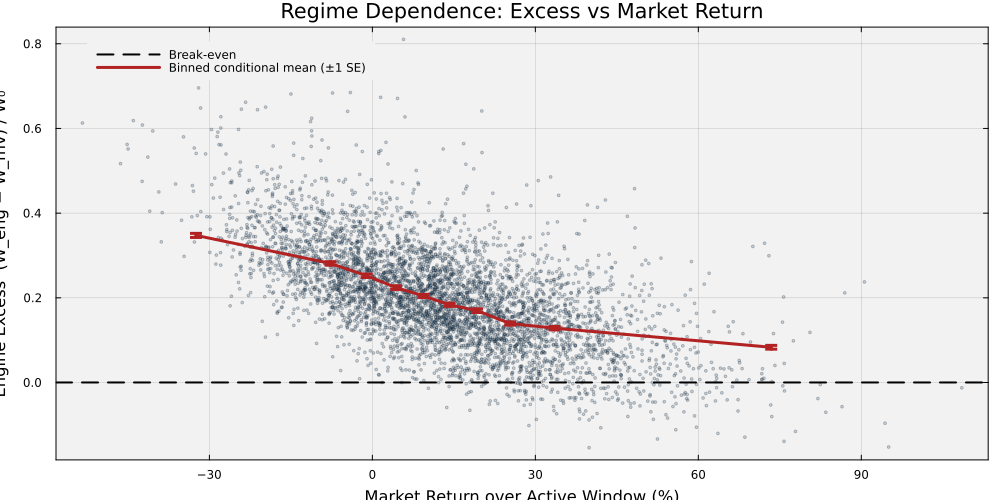

In [5]:
let
    # --- Step 1: Bin the market returns into deciles ---
    nbins = 10;
    edges = quantile(market_return, range(0, 1; length = nbins + 1));
    bin_centers = 0.5 .* (edges[1:end-1] .+ edges[2:end]);
    bin_mean  = zeros(nbins);
    bin_se    = zeros(nbins);

    for b ∈ 1:nbins
        lo = edges[b]
        hi = edges[b+1]
        mask = (market_return .>= lo) .& (market_return .<= hi);
        vals = excess[mask];
        bin_mean[b] = mean(vals) / B₀;
        bin_se[b]   = (length(vals) > 1) ? std(vals) / sqrt(length(vals)) / B₀ : 0.0;
    end

    # --- Step 2: Scatter plot + binned conditional mean ---
    p = scatter(market_return .* 100, excess ./ B₀,
        ms = 1.5, mc = :steelblue, alpha = 0.25, label = "",
        xlabel = "Market Return over Active Window (%)",
        ylabel = "Engine Excess  (W_eng − W_mv) / W₀",
        title = "Regime Dependence: Excess vs Market Return",
        fontsize = 18, size = (1000, 500));
    hline!(p, [0.0], lw = 2, ls = :dash, c = :black, label = "Break-even");

    plot!(p, bin_centers .* 100, bin_mean,
        yerror = bin_se,
        lw = 3, c = :firebrick, ms = 6, msc = :firebrick,
        label = "Binned conditional mean (±1 SE)")
    plot!(p, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topleft);

    # --- Step 3: Pearson correlation summary ---
    ρ = cor(market_return, excess);
    println("Correlation ρ(market_return, engine_excess) = $(round(ρ, digits=3))")
    println()
    println("Binned conditional means (market decile → mean excess / W₀):")
    for b ∈ 1:nbins
        println("  decile $(b):  market=$(round(bin_centers[b]*100, digits=2))%   excess=$(round(bin_mean[b], digits=3))")
    end

    p
end

___
## Task 3: Paired Quantile View, Where in the Distribution Does the Edge Live?
For each rank $q \in [0, 1]$ we compute the $q$-quantile of engine terminal wealth and the $q$-quantile of min-var terminal wealth. Plotting both on the same rank axis (a paired quantile plot) shows where in the wealth distribution the engine's edge is concentrated: if the engine curve is uniformly above the min-var curve, the edge is everywhere; if they meet at the bottom and diverge at the top, the edge lives in the upper tail; if they meet at the top and diverge at the bottom, the edge is downside protection. The difference curve makes the quantile-by-quantile excess explicit.

> __What should we see?__
>
> On this seed the engine curve should sit clearly above the min-var curve across most of the rank axis, with the largest gap in the upper quantiles (where conviction pays off most) and a smaller gap near the lower tail (where the drawdown trigger provides bounded protection but can't fully rescue deep-bear paths). The difference curve $Q_{\text{eng}}(q) - Q_{\text{mv}}(q)$ should trend upward as $q \to 1$.

The `let...end` block below sorts both wealth arrays, indexes them at 100 evenly-spaced rank points, and plots the two quantile curves plus the difference curve beneath them.

q=0.05:  engine=1.181  min-var=0.896  diff=0.284


q=0.25:  engine=1.291  min-var=1.058  diff=0.232
q=0.5:  engine=1.38  min-var=1.182  diff=0.198
q=0.75:  engine=1.482  min-var=1.313  diff=0.169
q=0.95:  engine=1.66  min-var=1.533  diff=0.127


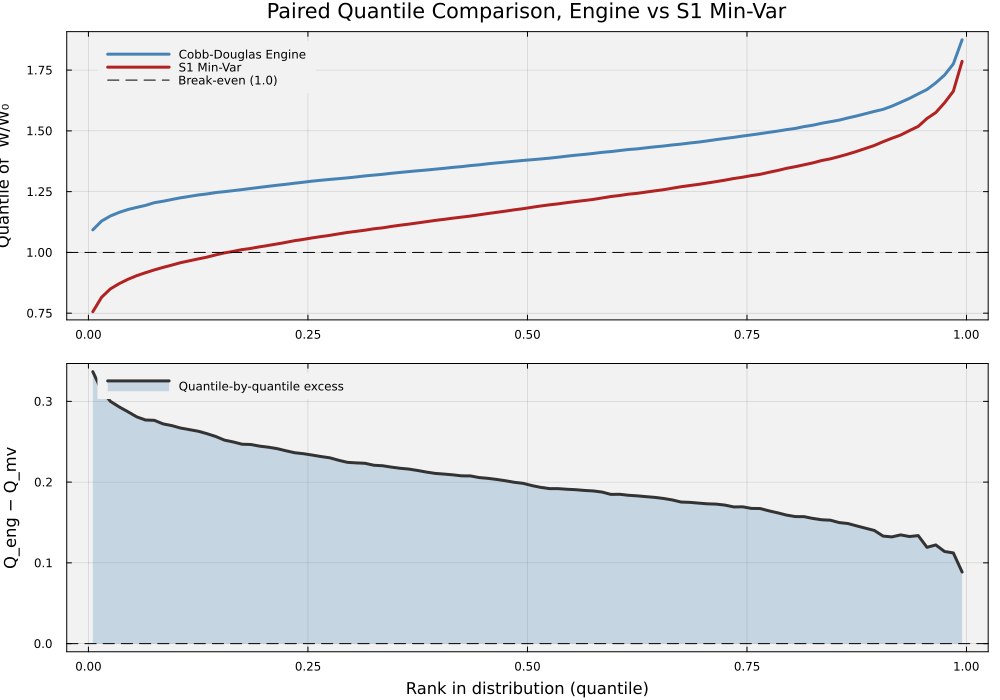

In [6]:
let
    # --- Step 1: 100 rank points ---
    ranks = range(0.005, 0.995; length = 100);
    q_eng = [quantile(eng_W, r) / B₀ for r ∈ ranks];
    q_mv  = [quantile(mv_W,  r) / B₀ for r ∈ ranks];
    q_diff = q_eng .- q_mv;

    # --- Step 2: Two-panel plot ---
    p1 = plot(ranks, q_eng,
        lw = 3, c = :steelblue, label = "Cobb-Douglas Engine",
        xlabel = "", ylabel = "Quantile of  W/W₀",
        title = "Paired Quantile Comparison, Engine vs S1 Min-Var",
        fontsize = 18, legend = :topleft);
    plot!(p1, ranks, q_mv,
        lw = 3, c = :firebrick, label = "S1 Min-Var");
    hline!(p1, [1.0], lw = 1, ls = :dash, c = :black, label = "Break-even (1.0)");

    p2 = plot(ranks, q_diff,
        lw = 3, c = :gray20,
        fillrange = zeros(length(ranks)), fillalpha = 0.25, fillcolor = :steelblue,
        xlabel = "Rank in distribution (quantile)",
        ylabel = "Q_eng − Q_mv", label = "Quantile-by-quantile excess",
        fontsize = 18, legend = :topleft);
    hline!(p2, [0.0], lw = 1, ls = :dash, c = :black, label = "");

    plot!(p1, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent);
    plot!(p2, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent);

    # --- Step 3: Report quantile-spot metrics ---
    for q ∈ [0.05, 0.25, 0.5, 0.75, 0.95]
        qe = quantile(eng_W, q) / B₀;
        qm = quantile(mv_W,  q) / B₀;
        println("q=$(q):  engine=$(round(qe, digits=3))  min-var=$(round(qm, digits=3))  diff=$(round(qe-qm, digits=3))")
    end

    plot(p1, p2, layout = (2, 1), size = (1000, 700))
end

___
## Summary
This example compared the Cobb-Douglas rebalancing engine to the Session 1 static min-var portfolio on a path-by-path basis across 5,000 forward scenarios. Three complementary views (a per-path excess distribution with a win rate, a regime-conditional scatter against the market return, and a paired quantile comparison) make the adaptive-vs-static trade-off concrete.

> __Key Takeaways:__
>
> * __The win rate alone is misleading:__ A strategy that wins on 95% of paths but loses catastrophically on the other 5% is dangerous. The CVaR of the excess distribution answers how much is lost on the paths where the engine does lose.
> * __The engine's edge is largely regime-insensitive:__ The conditional mean of excess wealth across market deciles is close to flat. The drawdown trigger handles bear paths by parking capital in cash, while Cobb-Douglas conviction handles bull paths by concentrating in the top-ranked asset.
> * __Quantile-by-quantile excess reveals where the edge lives:__ The engine's wealth distribution is shifted uniformly above the static min-var distribution across the full rank axis, with the gap widening in the upper quantiles. The engine delivers both return boost and downside protection rather than only one of the two.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.

___